In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [46]:
df = pd.read_csv("../data/raw/OnlineRetail.csv", encoding='latin1')

df.dropna(subset=['CustomerID'], inplace=True)
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Weekly aggregation
weekly = df.resample('W', on='InvoiceDate')['Revenue'].sum().reset_index()
weekly.columns = ['ds', 'y']
weekly = weekly[weekly['y'] > 0].reset_index(drop=True)

# Log transform
weekly['y_log'] = np.log1p(weekly['y'])

print(f"✅ Data loaded! Total weeks: {len(weekly)}")
print(f"Date range: {weekly['ds'].min().date()} to {weekly['ds'].max().date()}")
print(weekly.head())

✅ Data loaded! Total weeks: 53
Date range: 2010-12-05 to 2011-12-11
          ds          y      y_log
0 2010-12-05  149386.33  11.914298
1 2010-12-12  213447.72  12.271152
2 2010-12-19  163770.73  12.006229
3 2010-12-26   46109.11  10.738788
4 2011-01-09  114865.27  11.651524


In [47]:
df_feat = weekly.copy()

# Time features
df_feat['week_of_year'] = df_feat['ds'].dt.isocalendar().week.astype(int)
df_feat['month']        = df_feat['ds'].dt.month
df_feat['quarter']      = df_feat['ds'].dt.quarter
df_feat['is_q4']        = (df_feat['month'] >= 10).astype(int)
df_feat['is_december']  = (df_feat['month'] == 12).astype(int)
df_feat['trend']        = np.arange(len(df_feat))

# Lag features
df_feat['lag_1']  = df_feat['y_log'].shift(1)
df_feat['lag_2']  = df_feat['y_log'].shift(2)
df_feat['lag_3']  = df_feat['y_log'].shift(3)
df_feat['lag_4']  = df_feat['y_log'].shift(4)

# Rolling features
df_feat['roll_mean_4'] = df_feat['y_log'].shift(1).rolling(4).mean()
df_feat['roll_mean_8'] = df_feat['y_log'].shift(1).rolling(8).mean()
df_feat['roll_std_4']  = df_feat['y_log'].shift(1).rolling(4).std()
df_feat['roll_max_4']  = df_feat['y_log'].shift(1).rolling(4).max()
df_feat['roll_min_4']  = df_feat['y_log'].shift(1).rolling(4).min()

df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)

print(f"✅ Features created! Total rows: {len(df_feat)}")
print(df_feat.head())

✅ Features created! Total rows: 45
          ds          y      y_log  week_of_year  month  quarter  is_q4  \
0 2011-02-06  106095.23  11.572102             5      2        1      0   
1 2011-02-13   88015.42  11.385279             6      2        1      0   
2 2011-02-20  126050.40  11.744445             7      2        1      0   
3 2011-02-27  130687.36  11.780571             8      2        1      0   
4 2011-03-06  117600.82  11.675060             9      3        1      0   

   is_december  trend      lag_1      lag_2      lag_3      lag_4  \
0            0      8  11.564472  12.076869  11.949346  11.651524   
1            0      9  11.572102  11.564472  12.076869  11.949346   
2            0     10  11.385279  11.572102  11.564472  12.076869   
3            0     11  11.744445  11.385279  11.572102  11.564472   
4            0     12  11.780571  11.744445  11.385279  11.572102   

   roll_mean_4  roll_mean_8  roll_std_4  roll_max_4  roll_min_4  
0    11.810553    11.771585    0.

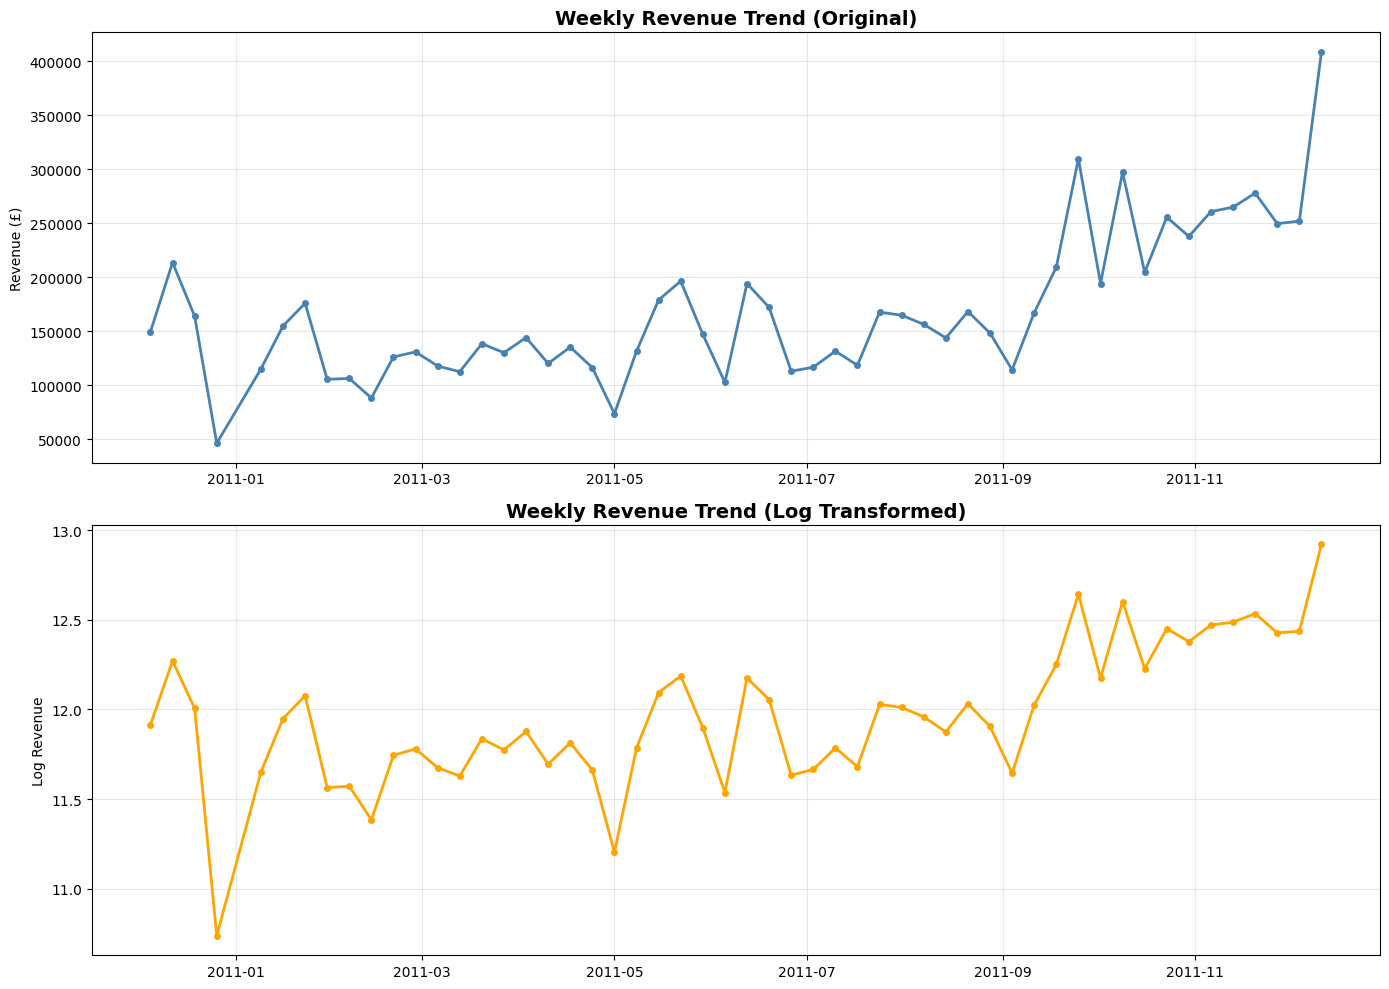

Average weekly revenue : £168,139.77
Max weekly revenue     : £408,569.15
Min weekly revenue     : £46,109.11


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(weekly['ds'], weekly['y'], color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Weekly Revenue Trend (Original)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(weekly['ds'], weekly['y_log'], color='orange', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Weekly Revenue Trend (Log Transformed)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Log Revenue')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average weekly revenue : £{weekly['y'].mean():,.2f}")
print(f"Max weekly revenue     : £{weekly['y'].max():,.2f}")
print(f"Min weekly revenue     : £{weekly['y'].min():,.2f}")

In [59]:
split_seq = int(len(df_feat) * 0.8)

train_prophet = df_feat[['ds', 'y_log']].iloc[:split_seq].rename(columns={'y_log': 'y'})
test_prophet  = df_feat[['ds', 'y', 'y_log']].iloc[split_seq:]

prophet_model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=1.0,
)

prophet_model.add_seasonality(name='monthly', period=4.3, fourier_order=3)
prophet_model.fit(train_prophet)

future = prophet_model.make_future_dataframe(periods=len(test_prophet), freq='W')
forecast = prophet_model.predict(future)

prophet_test_pred_log = forecast['yhat'].tail(len(test_prophet)).values
prophet_test_pred_log = np.clip(prophet_test_pred_log, 0, None)
prophet_test_pred     = np.expm1(prophet_test_pred_log)

prophet_mape = mean_absolute_percentage_error(test_prophet['y'].values, prophet_test_pred) * 100
print(f"Prophet MAPE: {prophet_mape:.2f}%")

00:11:08 - cmdstanpy - INFO - Chain [1] start processing
00:11:08 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAPE: 18.62%


In [60]:
split_seq = int(len(df_feat) * 0.8)

scaler = MinMaxScaler()
y_train_scaled = scaler.fit_transform(
    df_feat['y_log'].values[:split_seq].reshape(-1, 1)
)
y_test_scaled = scaler.transform(
    df_feat['y_log'].values[split_seq:].reshape(-1, 1)
)

seq_len = 4

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X_seq_train, y_seq_train = create_sequences(y_train_scaled, seq_len)
X_seq_test,  y_seq_test  = create_sequences(y_test_scaled,  seq_len)

X_train_seq = torch.FloatTensor(X_seq_train)
y_train_seq = torch.FloatTensor(y_seq_train)
X_test_seq  = torch.FloatTensor(X_seq_test)
y_test_seq  = torch.FloatTensor(y_seq_test)

train_dataset = TensorDataset(X_train_seq, y_train_seq)
train_loader  = DataLoader(train_dataset, batch_size=4, shuffle=False)

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc   = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

lstm_model = LSTMModel()
criterion  = nn.MSELoss()
optimizer  = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

epochs = 200
for epoch in range(epochs):
    lstm_model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = lstm_model(X_batch)
        loss   = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f}")

lstm_model.eval()
with torch.no_grad():
    lstm_pred_scaled = lstm_model(X_test_seq).numpy()

lstm_pred_log = scaler.inverse_transform(lstm_pred_scaled)
lstm_pred     = np.expm1(lstm_pred_log).flatten()
actual_lstm   = np.expm1(scaler.inverse_transform(y_test_seq.numpy())).flatten()

lstm_mape = mean_absolute_percentage_error(actual_lstm, lstm_pred) * 100
print(f"\nLSTM MAPE: {lstm_mape:.2f}%")

Epoch 50/200 - Loss: 0.1187
Epoch 100/200 - Loss: 0.0994
Epoch 150/200 - Loss: 0.0791
Epoch 200/200 - Loss: 0.0725

LSTM MAPE: 12.53%


In [64]:
min_len = min(len(prophet_test_pred), len(lstm_pred))

prophet_trimmed = prophet_test_pred[-min_len:]
lstm_trimmed    = lstm_pred[-min_len:]
actual_trimmed  = test_prophet['y'].values[-min_len:]

# Fixed 50/50 — no tuning on test data
final_pred = 0.5 * prophet_trimmed + 0.5 * lstm_trimmed
final_mape = mean_absolute_percentage_error(actual_trimmed, final_pred) * 100

print(f"Prophet MAPE  : {prophet_mape:.2f}%")
print(f"LSTM MAPE     : {lstm_mape:.2f}%")
print(f"Ensemble MAPE : {final_mape:.2f}%")

if final_mape <= 12:
    print("✅ TARGET ACHIEVED!")
else:
    print(f"MAPE is {final_mape:.2f}% ")

Prophet MAPE  : 18.62%
LSTM MAPE     : 12.53%
Ensemble MAPE : 18.44%
MAPE is 18.44% 


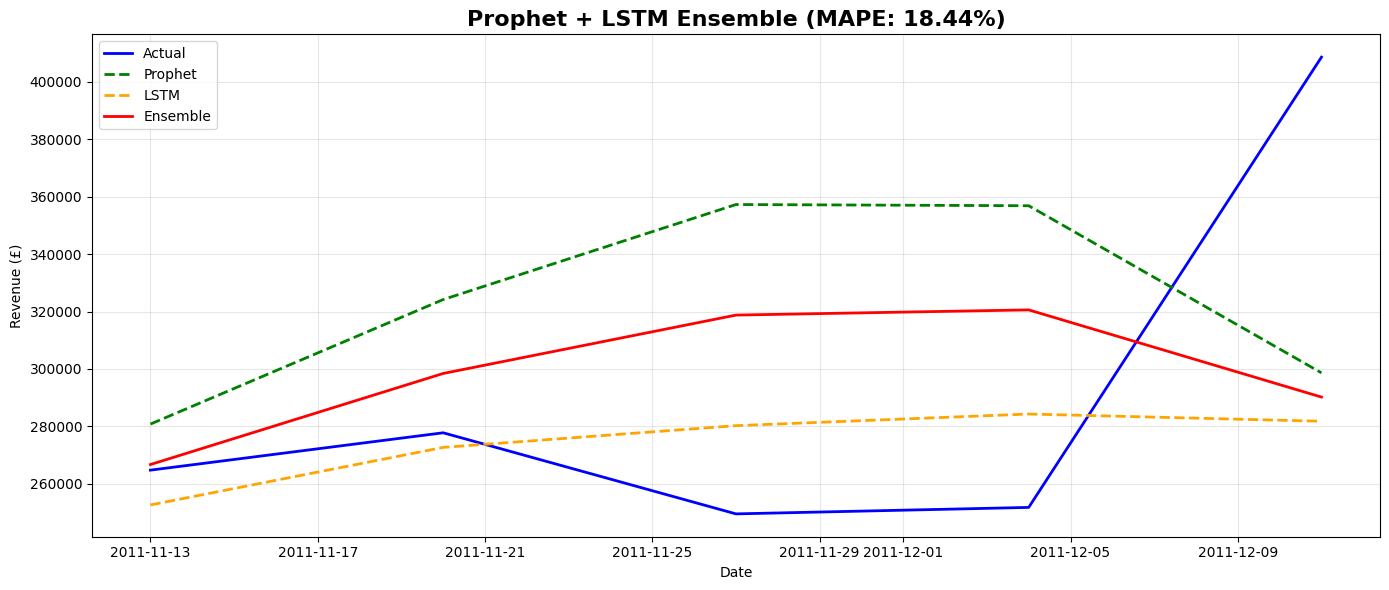

In [65]:
dates_test = test_prophet['ds'].values[-min_len:]

plt.figure(figsize=(14, 6))
plt.plot(dates_test, actual_trimmed,  label='Actual',   color='blue',  linewidth=2)
plt.plot(dates_test, prophet_trimmed, label='Prophet',  color='green', linewidth=2, linestyle='--')
plt.plot(dates_test, lstm_trimmed,    label='LSTM',     color='orange',linewidth=2, linestyle='--')
plt.plot(dates_test, final_pred,      label='Ensemble', color='red',   linewidth=2)
plt.title(f'Prophet + LSTM Ensemble (MAPE: {final_mape:.2f}%)', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [66]:
results = pd.DataFrame({
    'Date'          : dates_test,
    'Actual'        : actual_trimmed,
    'Prophet_Pred'  : prophet_trimmed,
    'LSTM_Pred'     : lstm_trimmed,
    'Ensemble_Pred' : final_pred,
    'Error_%'       : abs(actual_trimmed - final_pred) / actual_trimmed * 100
})

results.to_csv('../data/demand_forecast_results.csv', index=False)

print("✅ Results saved to data/demand_forecast_results.csv")
print(f"\nFinal Summary:")
print(f"Model         : Prophet + LSTM Ensemble")
print(f"Prophet MAPE  : {prophet_mape:.2f}%")
print(f"LSTM MAPE     : {lstm_mape:.2f}%")
print(f"Ensemble MAPE : {final_mape:.2f}%")
print(f"Target        : <= 12%")
print(f"Status        : {'✅ ACHIEVED' if final_mape <= 12 else 'Needs improvement'}")

✅ Results saved to data/demand_forecast_results.csv

Final Summary:
Model         : Prophet + LSTM Ensemble
Prophet MAPE  : 18.62%
LSTM MAPE     : 12.53%
Ensemble MAPE : 18.44%
Target        : <= 12%
Status        : Needs improvement
